# Diabetes Risk Factor Analysis

**A reproducible analytical workflow prepared for cross site data science review.**

**Created by: Pritish Ponaka**

## Purpose and Overview

This notebook explores risk factors associated with a diabetes diagnosis using a patient level dataset with nine clinical and demographic variables. It was originally developed for internal exploratory analysis at a teaching hospital within a multi site academic health system, and has since been revised so that the data science team at another clinical site in the same health system can obtain the project files, understand the workflow, execute the notebook in their own environment, and reproduce the results without needing to contact the original author.

**What this notebook does, in order:**
1. Sets up the required programming environment.
2. Documents the dataset source and structure.
3. Loads and validates the data.
4. Prepares the data for analysis, including handling a dataset specific missing data issue.
5. Runs descriptive statistics, visualizations, a correlation matrix, and two inferential statistical tests.
6. Frames the analysis as a formal statistical and machine learning problem.
7. Runs a reproducibility check to confirm results are stable across executions.
8. Summarizes results and conclusions, including limitations.

**Audience and assumptions:** this notebook assumes the reader is a data scientist or analyst comfortable with Python, pandas, and basic inferential statistics, but assumes no prior knowledge of this specific project or dataset. Every section below explains what it does and why, so the notebook can be run and understood independently.

## 1. Setup and Environment

**Purpose:** get this project's files onto your own machine, get every required package available, and fix a random seed so that any step involving random sampling produces the same result on every run.

**Step 0: get the repository (needed before either option below):**
```
git clone https://github.com/pritishponaka/Diabetes-Risk-Factor-Analysis.git
cd Diabetes-Risk-Factor-Analysis
```
This gives you the notebook, `Example_Dataset_Diabetes.csv`, `requirements.txt`, `requirements-lock.txt`, and this README, all in one folder together. Run the commands in both options below from inside that cloned folder, not from some other directory, since Option 1's `pip install` and this notebook's relative `DATA_PATH` both assume the CSV and requirements files are sitting right next to it.

If you're working in Google Colab instead of a local clone: upload the notebook and `Example_Dataset_Diabetes.csv` directly into your Colab session (or mount the cloned folder from Google Drive), then skip straight to Option 2 below.

Two ways to handle dependencies once you have the files, pick whichever fits how you work.

**Option 1: you manage the environment yourself (recommended for local development):**
1. Use Python 3.10 or later.
2. Create a virtual environment:
   ```
   python -m venv venv
   source venv/bin/activate
   ```
   On Windows, use `venv\Scripts\activate` instead of the `source` command above.
3. Install exact, validated versions:
   ```
   pip install -r requirements-lock.txt
   ```
   (`requirements-lock.txt` pins the full dependency tree, not just the packages this notebook directly imports; `requirements.txt` lists just those direct imports, for reference.)
4. Skip the "Option 2" cell below and run the imports cell after it.

**Option 2: just run the notebook (recommended for Google Colab, or to skip setting up a virtual environment):**
* Run the "Automatic dependency check" cell below before the imports cell. It checks for each required package and installs only whatever is missing.
* Safe to run even if you already did Option 1: if everything is already installed, this cell finds nothing missing and does nothing.
* In Google Colab, most of these packages are already preinstalled, so this cell will typically report little or nothing to install.

**Assumptions and limitations:**
* This notebook assumes a standard CPython environment. No GPU is required.
* The automatic install in Option 2 requires internet access and permission to install packages in the current environment. On a locked-down or offline machine, use Option 1 with a pre-approved `requirements-lock.txt` instead.
* All random sampling in this notebook (see the Reproducibility Check section near the end) uses a fixed seed, defined once below, so results are stable across runs. Do not remove or change this seed without re validating downstream results.

In [1]:
# Automatic dependency check and install (Option 2). Safe to run whether or not you already did Option 1: if everything required is already
# installed, this finds nothing missing and does nothing.
import importlib
import subprocess
import sys

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "plotly": "plotly",
}

missing = [
    pip_name for import_name, pip_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are already installed.")

All required packages are already installed.


In [2]:
# Load required packages
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path  # for robust, cross-platform file paths, used in Data Loading below
from scipy.stats import ttest_ind, chi2_contingency  # statistical tests used in Inferential Analysis
import plotly # this is for the Sankey
import plotly.graph_objects as go # this is for the Sankey

# Setting the seed for random sampling to reproduce the same results with every run and throughout the notebook.
RANDOM_SEED = 99  # fun fact: Wayne Gretzsky's Jersey #
# numpy and Python's built-in random module each keep their own separate random state, so both need to be seeded.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Make sure the versions match the requirements.txt.
print(f"pandas version:    {pd.__version__}")
print(f"numpy version:     {np.__version__}")
print(f"matplotlib version:{plt.matplotlib.__version__}")
print(f"seaborn version:   {sns.__version__}")
print(f"plotly version:   {plotly.__version__}")

pandas version:    3.0.2
numpy version:     2.4.4
matplotlib version:3.10.8
seaborn version:   0.13.2
plotly version:   7.1.0


### User edits

Before running the rest of this notebook, review the two settings below. These are the only values you should need to change to run this notebook in your own environment. Everything past this point uses them automatically.

In [3]:
# ****************************************USER EDITS*******************************************************

# update these two values for your environment.
# Everything else in this notebook uses them automatically.

# Local path to the dataset. Change only if your file lives somewhere other than right next to this notebook.
DATA_PATH = Path("Example Dataset_Diabetes.csv")

# Fallback URL used only if DATA_PATH is not found locally. Must be a raw file URL (raw.githubusercontent.com/...), not a normal GitHub
# page URL (github.com/.../blob/...). Replace the placeholder below once the dataset has been uploaded to a public repository.
DATA_URL = "https://raw.githubusercontent.com/pritishponaka/Diabetes-Risk-Factor-Analysis/refs/heads/main/Example%20Dataset_Diabetes.csv"

# ************************************END USER EDITS*******************************************************

## 2. Data Source and Provenance

**Dataset:** this project uses the diabetes dataset provided with this analysis, `Example_Dataset_Diabetes.csv`. It contains diagnostic measurements for 768 patient records along with a binary outcome indicating a diabetes diagnosis. This file is the only data source for this project. No other version or copy should be substituted.

This dataset is provided for methodological development and demonstration purposes. Unless your team has separately verified its clinical provenance and consent or IRB status, treat results in this notebook as illustrative of the analytical workflow rather than as validated clinical findings, and do not present them as characterizing our patient population without further review.

**Columns in this file:**

| Column          | Description |
|-----------------|-------------|
| Pregnancies     | Number of pregnancies |
| Glucose         | Plasma glucose concentration |
| D_BP            | Diastolic blood pressure, in mm Hg |
| Skin_Thickness  | Triceps skinfold thickness, in mm |
| Insulin         | Serum insulin, in mu U per ml |
| BMI             | Body mass index |
| Pedigree        | Diabetes pedigree function, a composite genetic risk score |
| Age             | Age in years |
| Outcome         | 1 indicates a diabetes diagnosis, 0 indicates no diagnosis |

**Known, dataset specific limitation:** several columns use a literal value of 0 as a placeholder for missing data, rather than a standard missing value. This is confirmed in Data Validation below and corrected in Data Preparation. Do not interpret 0 values in `Glucose`, `D_BP`, `Skin_Thickness`, `Insulin`, or `BMI` as real measurements.

## 3. Data Loading

**Purpose:** load the dataset and confirm it matches the structure described above before any analysis begins.

**How this works:** this notebook first looks for the file at `DATA_PATH`, set in Setup and Environment above. If it is not found there, it falls back to downloading the same file from `DATA_URL`, also set above. Whichever source is used, the notebook prints it clearly below, so you always know which copy of the data you are working with. There is nothing to change in this section itself, if you need to point this notebook at a different file or URL, edit `DATA_PATH` or `DATA_URL` in Setup and Environment.

In [4]:
if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    data_source = "LOCAL FILE"
    data_source_detail = str(DATA_PATH.resolve())
else:
    try:
        df = pd.read_csv(DATA_URL)
        data_source = "GITHUB (fallback)"
        data_source_detail = DATA_URL
    except Exception as e:
        raise FileNotFoundError(
            f"Could not find '{DATA_PATH}' locally, and could not load it "
            f"from DATA_URL either (error: {e}). Either place the CSV file "
            f"next to this notebook, or set DATA_URL to a working raw "
            f"GitHub URL for the dataset."
        ) from e

print(f"Data source used: {data_source}")
print(f"Location: {data_source_detail}")

EXPECTED_COLUMNS = [
    "Pregnancies", "Glucose", "D_BP", "Skin_Thickness",
    "Insulin", "BMI", "Pedigree", "Age", "Outcome"
]

print(f"Rows, columns: {df.shape}")
print(f"Column names: {list(df.columns)}")

assert list(df.columns) == EXPECTED_COLUMNS, (
    "Column names or order differ from what this notebook expects. "
    "Check that you have the correct, unmodified source file."
)

df.head()

Data source used: LOCAL FILE
Location: C:\Users\f003cc3\Documents\hds\HSE 751 Programming for HDS\Week2\Example Dataset_Diabetes.csv
Rows, columns: (768, 9)
Column names: ['Pregnancies', 'Glucose', 'D_BP', 'Skin_Thickness', 'Insulin', 'BMI', 'Pedigree', 'Age', 'Outcome']


,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


What to check here before continuing: the shape should show 768 rows and 9 columns, and the column names should exactly match the 9 fields listed in Data Source and Provenance above. If the assertion fails, stop here. It means the loaded file does not match the expected structure, and any downstream results would not be reliable.

## 4. Data Validation

**Purpose:** confirm that the loaded dataset is structurally sound and check specifically for the disguised missing data issue described above, since a standard `isna` check will not detect it.

**What to check:**
* Data types match expectations, and there are no unexpected nulls.
* Zero value counts in `Glucose`, `D_BP`, `Skin_Thickness`, `Insulin`, and `BMI` are reviewed, not ignored.
* No duplicate patient records.
* `Outcome` only contains 0 and 1, and its class balance is understood, since that affects how later statistical tests should be interpreted.

In [5]:
print("Data types:")                 # Data types
print(df.dtypes)

print("\nMissing values (NaN style):")        # traditional NULL values
print(df.isna().sum())

# Dataset specific check: a value of 0 is not physiologically plausible for these five columns, so a standard isna() check will not catch this 
# form of missing data. We check explicitly.
zero_as_missing_cols = ["Glucose", "D_BP", "Skin_Thickness", "Insulin", "BMI"]

print("\nZero counts in columns where 0 is not physiologically plausible:")
zero_counts = (df[zero_as_missing_cols] == 0).sum()
print(zero_counts)
print("\nPercent of rows affected per column:")
print((zero_counts / len(df) * 100).round(1).astype(str) + "%")

n_duplicates = df.duplicated().sum()     # duplicate check
print(f"\nDuplicate rows: {n_duplicates}")

print("\nOutcome value counts (class balance):")
print(df["Outcome"].value_counts())
assert set(df["Outcome"].unique()) <= {0, 1}, (
    "Outcome contains values other than 0/1. Check the source file for corruption."
)

print(f"\nAge range: {df['Age'].min()} to {df['Age'].max()}")          # Check for plausible values in the age column.
assert df["Age"].min() > 0, "Found a non positive age. Check the source file."

Data types:
Pregnancies         int64
Glucose             int64
D_BP                int64
Skin_Thickness      int64
Insulin             int64
BMI               float64
Pedigree          float64
Age                 int64
Outcome             int64
dtype: object

Missing values (NaN style):
Pregnancies       0
Glucose           0
D_BP              0
Skin_Thickness    0
Insulin           0
BMI               0
Pedigree          0
Age               0
Outcome           0
dtype: int64

Zero counts in columns where 0 is not physiologically plausible:
Glucose             5
D_BP               35
Skin_Thickness    227
Insulin           374
BMI                11
dtype: int64

Percent of rows affected per column:
Glucose            0.7%
D_BP               4.6%
Skin_Thickness    29.6%
Insulin           48.7%
BMI                1.4%
dtype: str

Duplicate rows: 0

Outcome value counts (class balance):
Outcome
0    500
1    268
Name: count, dtype: int64

Age range: 21 to 81


**Interpreting this output:** the zero counts table shows how much disguised missing data exists per column. `Insulin` and `Skin_Thickness` are affected the most, while `Glucose`, `D_BP`, and `BMI` are affected only slightly. `Outcome` is imbalanced, with roughly twice as many patients without a diagnosis as with one, which is addressed when interpreting later statistical tests. There are no duplicate rows in this dataset.

## 5. Data Preparation

**Purpose:** correct the disguised missing data identified above, and derive one additional variable used later in the Inferential Analysis section.

**Preprocessing decision:** the 0 values in `Glucose`, `D_BP`, `Skin_Thickness`, `Insulin`, and `BMI` are first converted to proper missing values, then imputed using the median of each column, calculated separately within each `Outcome` group. Grouping the median by `Outcome` avoids letting the imputation blur the very difference between groups that this analysis is examining. All downstream sections use this cleaned dataset, stored as `df_clean`, rather than the raw `df`.

**Limitation:** median imputation is a simple approach, but it does not model the relationships between variables the way a more advanced imputation method would. Given the moderate proportion of missing data in most affected columns, I treated this as acceptable for this exploratory analysis, but a more rigorous imputation approach should be considered before any clinical use of these results.

A `BMI_Category` column is also created here, using standard clinical BMI thresholds, for use in the Chi square test later in this notebook.

In [6]:
df_clean = df.copy()      # Store clean dataset in df_clean data frame.

for col in zero_as_missing_cols:                    #  loop thorugh columns with 0 as missing and replace them with NULLs
    df_clean[col] = df_clean[col].replace(0, np.nan)

# Median imputation, computed separately within each Outcome group, so imputed values reflect the typical patient in that specific outcome
# group rather than the overall population.
for col in zero_as_missing_cols:                                 # imputation based on median.
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(
        lambda s: s.fillna(s.median())
    )

assert df_clean[zero_as_missing_cols].isna().sum().sum() == 0, (
    "Imputation did not remove all missing values. Investigate before continuing."
)
print("Missing values after imputation:")
print(df_clean[zero_as_missing_cols].isna().sum())


def bmi_category(bmi_value):            # function for bmi category values
    """Map a BMI value to a standard clinical BMI category."""
    if bmi_value < 18.5:
        return "Underweight"
    elif bmi_value < 25:
        return "Normal"
    elif bmi_value < 30:
        return "Overweight"
    else:
        return "Obese"


df_clean["BMI_Category"] = df_clean["BMI"].apply(bmi_category)
df_clean.head()

Missing values after imputation:
Glucose           0
D_BP              0
Skin_Thickness    0
Insulin           0
BMI               0
dtype: int64


,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome,BMI_Category
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1,Obese
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0,Overweight
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1,Normal
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Overweight
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Obese


## 6. Analysis

This section covers descriptive statistics, visualizations, a correlation matrix, two inferential statistical tests, and a formal statement of the analysis as a statistical and machine learning problem. Every step in this section uses `df_clean` from Data Preparation above, not the raw `df`.

### 6.1 Descriptive Statistics

**Purpose:** summarize the center and spread of each numeric variable, using the corrected data from Data Preparation. These summaries are the foundation for the visualizations and inferential tests that follow.

In [7]:
df_clean.describe()

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Mean and standard deviation.** The sample mean summarizes the center of a set of observations:

$$
\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

where $\bar{x}$ is the sample mean, $x_i$ is each individual observation, and $n$ is the total number of observations.

The sample standard deviation summarizes how much the observations vary around that center:

$$
s = \sqrt{ \frac{1}{n - 1} \sum_{i=1}^{n} (x_i - \bar{x})^2 }
$$

where $s$ is the sample standard deviation, $x_i$ is each individual observation, $\bar{x}$ is the sample mean, and $n$ is the total number of observations.

In this dataset, these two statistics are concrete. The mean `Glucose` value gives a single reference point for typical glucose readings, and comparing that mean between the two `Outcome` groups, shown numerically in Inferential Analysis below and visually in Visualizations, is one of the clearest signals in the dataset, since elevated glucose is part of the diagnostic criteria for diabetes. The standard deviation of `BMI` shows how much body mass index varies across patients, which matters when interpreting any result that uses `BMI` as a factor. `Age` and `Pregnancies` are counts with a natural scale, so their mean and standard deviation can be read directly as the typical patient value and how much patients differ from it.

### 6.2 Visualizations

**Purpose:** build on the descriptive statistics above with visual summaries. Univariate plots show the distribution of a single variable. Bivariate plots show how two variables relate to each other, which is often more informative for spotting patterns tied to diabetes outcome.

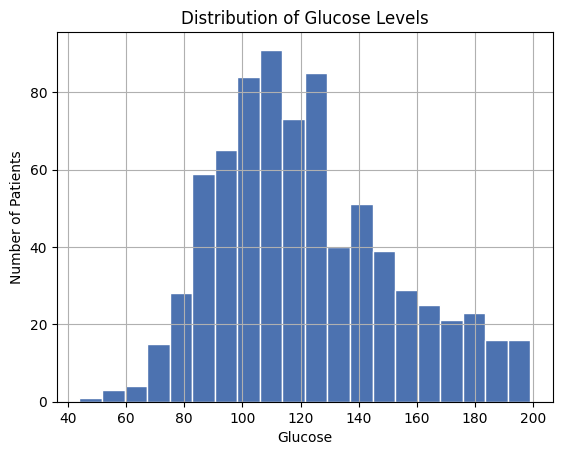

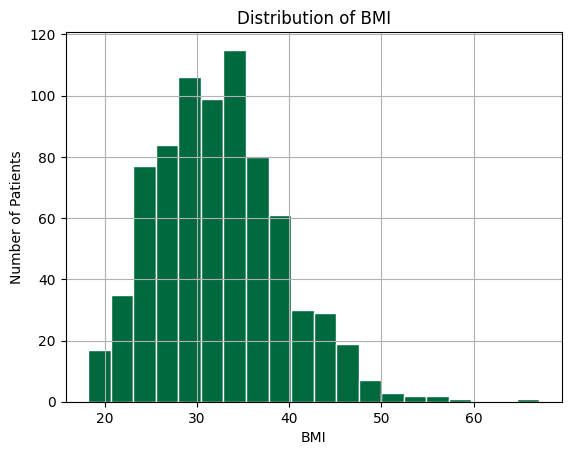

In [8]:
# Histogram of Glucose. Uses df_clean (post imputation), not the raw df,
# so the disguised zero values corrected in Data Preparation don't distort
# the shape of this distribution.
plt.figure()
df_clean["Glucose"].hist(bins=20, color="#4C72B0", edgecolor="white")
plt.title("Distribution of Glucose Levels")
plt.xlabel("Glucose")
plt.ylabel("Number of Patients")
plt.show()

# Same as above, for BMI. A separate plt.figure() call keeps this on its
# own figure rather than overlaying onto the Glucose histogram above.
plt.figure()
df_clean["BMI"].hist(bins=20, color="#00693e", edgecolor="white")
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")
plt.show()

**BMI category and diabetes outcome, as a Sankey diagram.** `BMI_Category` and `Outcome` are both categorical, so a Sankey diagram is a natural fit: it shows how patients in each `BMI_Category` split across the two `Outcome` groups, with each flow's width proportional to patient count. This is built directly with matplotlib below, so there is no extra library to install: matplotlib is already required for every other chart in this notebook.

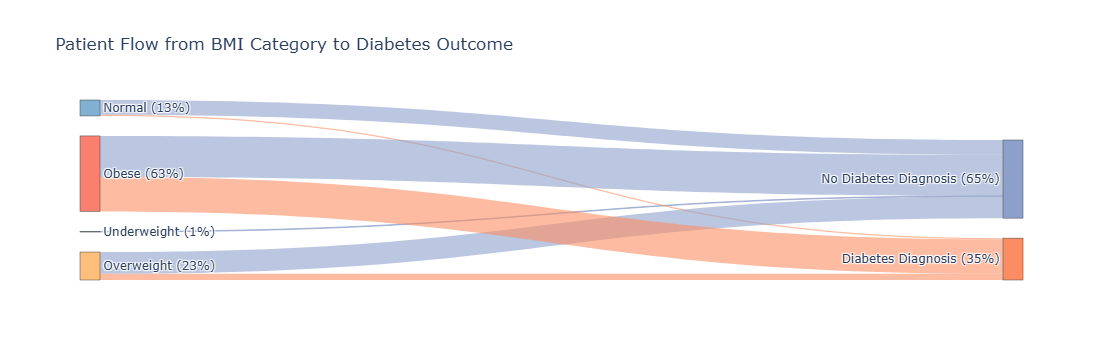

In [9]:
# Sankey plot

bmi_order = ["Underweight", "Normal", "Overweight", "Obese"]
outcome_names = ["No Diabetes Diagnosis", "Diabetes Diagnosis"]

flow_counts = (
    pd.crosstab(df_clean["BMI_Category"], df_clean["Outcome"])
    .reindex(index=bmi_order, columns=[0, 1])  # lock in row/column order to match bmi_order and outcome 0/1
    .fillna(0)  # a BMI category with zero patients for a given outcome would otherwise show as NaN, not 0
)
total_patients = flow_counts.values.sum()

# Build each side's label with its share of the total dataset, for example: "Obese (62%)" or "No Diabetes Diagnosis (65%)", so proportion is
# visible directly on the diagram rather than only via hover.
left_totals = flow_counts.sum(axis=1)
left_labels = [
    f"{cat} ({left_totals[cat] / total_patients:.0%})" for cat in bmi_order
]
right_totals = flow_counts.sum(axis=0)
right_labels = [
    f"{outcome_names[j]} ({right_totals[j] / total_patients:.0%})" for j in [0, 1]
]
all_labels = left_labels + right_labels

# Translucent versions of this notebook's standard outcome colors (blue = no diagnosis, orange = diabetes diagnosis), used to color
# each curve by its destination rather than its BMI category origin.
outcome_link_colors = {
    0: "rgba(141, 160, 203, 0.6)",   # translucent #8DA0CB
    1: "rgba(252, 141, 98, 0.6)",    # translucent #FC8D62
}

sources, targets, values, link_colors = [], [], [], []
for i, bmi_cat in enumerate(bmi_order):
    for j in [0, 1]:
        sources.append(i)
        targets.append(len(bmi_order) + j)  # offset into the Outcome labels, since they come after bmi_order in all_labels
        values.append(flow_counts.loc[bmi_cat, j])
        link_colors.append(outcome_link_colors[j])  # curve color follows destination, not origin

fig = go.Figure(go.Sankey(
    node=dict(
        label=all_labels,
        color=["#8ECFC9", "#82B0D2", "#FFBE7A", "#FA7F6F", "#8DA0CB", "#FC8D62"]
    ),
    link=dict(source=sources, target=targets, value=values, color=link_colors)
))
fig.update_layout(title_text="Patient Flow from BMI Category to Diabetes Outcome", font_size=12)
fig.show()

**Interpretation:** the `Obese` category is both the largest group in this dataset, at 63% of all patients, and the group with the largest share flowing into a diabetes diagnosis: nearly 46% of Obese patients received a diagnosis, compared to 22% of Overweight patients, 7% of Normal weight patients, and 0% of the 4 Underweight patients. The `Normal` and `Underweight` categories are small and flow overwhelmingly toward no diagnosis. This is a visual companion to the chi square test in Inferential Analysis below, which formally tests whether this pattern is stronger than chance.

**Glucose distribution by diabetes outcome, as a ridgeline plot.** A ridgeline plot stacks a density curve per group so their shapes can be compared directly. This adapts the two group case of the approach shown at [python-graph-gallery.com: Ridgeline chart with python](https://python-graph-gallery.com/ridgeline-graph-seaborn/), which uses a Seaborn `FacetGrid` of `kdeplot` calls, one row per group.

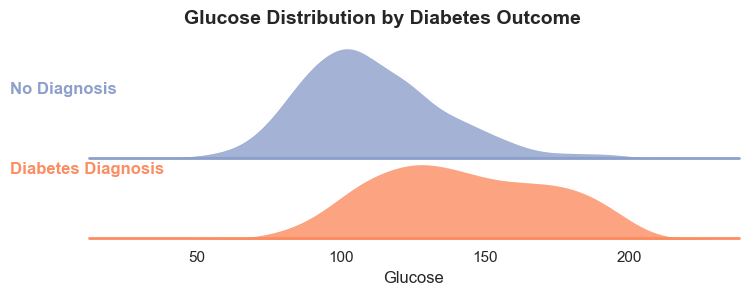

In [10]:
# Ridgeplot bi-variate plot

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})  # transparent axes background, needed for the overlapping ridgeline effect below

ridge_df = df_clean[["Glucose", "Outcome"]].copy()
ridge_df["Outcome_Label"] = ridge_df["Outcome"].map(
    {0: "No Diagnosis", 1: "Diabetes Diagnosis"}
)
row_order = ["No Diagnosis", "Diabetes Diagnosis"]  # fixes top to bottom row order, since otherwise it's not guaranteed
pal = {"No Diagnosis": "#8DA0CB", "Diabetes Diagnosis": "#FC8D62"}  # same blue/orange used elsewhere in this notebook

g = sns.FacetGrid(
    ridge_df, row="Outcome_Label", row_order=row_order,  # one row per outcome group, in row_order
    hue="Outcome_Label", hue_order=row_order, palette=pal,  # hue_order must match row_order or colors will mismatch rows
    aspect=5, height=1.5  # wide, short panels
)

g.map(sns.kdeplot, "Glucose", bw_adjust=1, clip_on=False,  # clip_on=False lets curves overlap into neighboring rows
      fill=True, alpha=0.8, linewidth=1.5)
g.map(sns.kdeplot, "Glucose", bw_adjust=1, clip_on=False,  # second pass: a plain white outline drawn on top, no fill
      color="w", lw=2)
g.map(plt.axhline, y=0, lw=2, clip_on=False)  # baseline under each curve, in that row's color via FacetGrid's hue

for ax, label in zip(g.axes.flat, row_order):  # g.axes.flat order matches row_order, set above
    ax.text(-15, 0.01, label, fontweight="bold", fontsize=12,
            color=pal[label])  # label placed directly on the plot instead of a legend, color-matched to its curve

g.fig.subplots_adjust(hspace=-0.3)  # negative spacing so rows overlap, which is what makes this a ridgeline rather than stacked subplots
g.set_titles("")  # remove FacetGrid's default per-row titles, since the text labels above replace them
g.set(yticks=[])  # density scale isn't meaningful to compare directly across curves here, so hide it
g.set_ylabels("")  # avoid "Density" overlapping the text labels added above
g.despine(bottom=True, left=True)  # drop axis lines for a cleaner, open look
g.fig.suptitle("Glucose Distribution by Diabetes Outcome",
               fontsize=14, fontweight="bold")
plt.show()

**Interpretation:** the `Diabetes Diagnosis` curve is shifted noticeably to the right of the `No Diagnosis` curve, showing higher typical `Glucose` values among diagnosed patients, with partial overlap between the two. This is the same underlying relationship the t test in Inferential Analysis below quantifies directly; the ridgeline shows the full shape of each group's distribution rather than only its center and spread. The full set of pairwise relationships across all variables is examined next.

### 6.3 Correlation Matrix

**Purpose:** the plots above show two specific variable pairs. This section summarizes every pairwise relationship among the numeric variables at once, so patterns that were not specifically plotted are still visible.

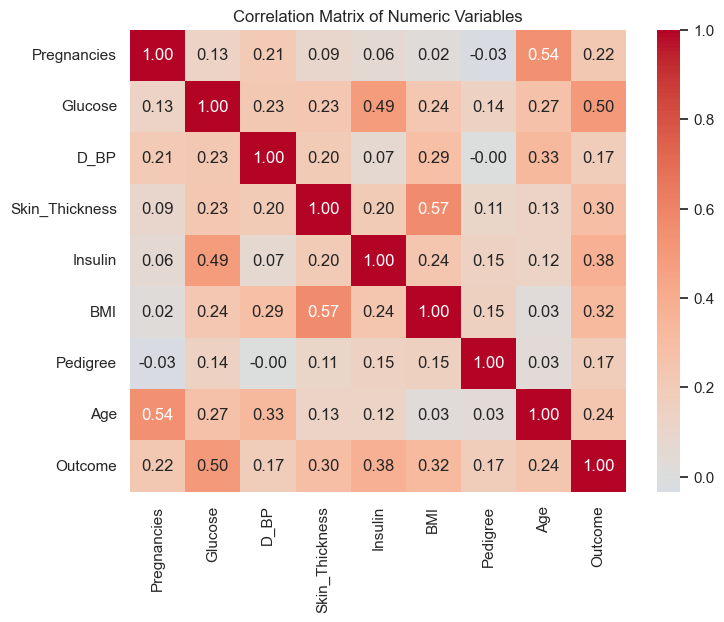

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
Pregnancies,1.00,0.13,0.21,0.09,0.06,0.02,-0.03,0.54,0.22
Glucose,0.13,1.00,0.23,0.23,0.49,0.24,0.14,0.27,0.50
D_BP,0.21,0.23,1.00,0.20,0.07,0.29,-0.00,0.33,0.17
Skin_Thickness,0.09,0.23,0.20,1.00,0.20,0.57,0.11,0.13,0.30
Insulin,0.06,0.49,0.07,0.20,1.00,0.24,0.15,0.12,0.38
BMI,0.02,0.24,0.29,0.57,0.24,1.00,0.15,0.03,0.32
Pedigree,-0.03,0.14,-0.00,0.11,0.15,0.15,1.00,0.03,0.17
Age,0.54,0.27,0.33,0.13,0.12,0.03,0.03,1.00,0.24
Outcome,0.22,0.50,0.17,0.30,0.38,0.32,0.17,0.24,1.00


In [11]:
# Correlation matrix
corr_matrix = df_clean.drop(columns=["BMI_Category"]).corr(numeric_only=True)  # drop BMI_Category, since it's categorical text, not numeric

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)  # center=0 keeps 0 correlation at the midpoint of the color scale
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

corr_matrix.round(2)  # printed as a table too, since exact values are hard to read off the heatmap's color alone

**Interpretation:** the strongest pairwise relationship in the full dataset is between `Skin_Thickness` and `BMI`, both measures related to body composition. The second strongest is between `Pregnancies` and `Age`, which fits, since older patients in this dataset have generally had more pregnancies. Looking specifically at `Outcome`, `Glucose` has the strongest relationship with diabetes status among all variables, followed by `Insulin` and `BMI`. This supports focusing the Inferential Analysis below on `Glucose` and on `BMI`, since both show a meaningful relationship with `Outcome` in this correlation matrix.

### 6.4 Inferential Analysis

This section moves from description to formal statistical testing, evaluating whether patterns seen above are unlikely to be due to chance alone. Two tests are used because they answer two different kinds of questions about this dataset.

**Independent samples t test: Glucose by diabetes outcome.** Purpose: test whether mean `Glucose` differs between patients with and without a diabetes diagnosis.

$$
t = \frac{\bar{x}_1 - \bar{x}_0}{\sqrt{\dfrac{s_1^2}{n_1} + \dfrac{s_0^2}{n_0}}}
$$

where $\bar{x}_1$ and $\bar{x}_0$ are the mean `Glucose` values for the diabetes and no diabetes groups, $s_1^2$ and $s_0^2$ are the corresponding sample variances, and $n_1$ and $n_0$ are the group sample sizes. This test evaluates whether the difference between the two group means is larger than expected from random sampling variation alone, assuming the true population means were equal.

In [12]:
# Independent t-test
group_0 = df_clean.loc[df_clean["Outcome"] == 0, "Glucose"]  # Glucose values for patients without a diabetes diagnosis
group_1 = df_clean.loc[df_clean["Outcome"] == 1, "Glucose"]  # Glucose values for patients with a diabetes diagnosis

t_stat, p_value = ttest_ind(group_0, group_1)  # default equal_var=True (Student's t test); Welch's t test would be used if variances differed substantially
print("t statistic:", t_stat)
print("p value:", p_value)
print("\nGroup means:")
print(df_clean.groupby("Outcome")["Glucose"].mean().round(1))  # supports interpreting the direction and size of the difference behind the p value above

t statistic: -15.808983160790056
p value: 6.2269331337017874e-49

Group means:
Outcome
0    110.6
1    142.3
Name: Glucose, dtype: float64


**Result and interpretation:** the mean `Glucose` level is noticeably higher for patients with a diabetes diagnosis than for patients without one, and the resulting p value is far below 0.05. We reject the null hypothesis of equal means. This confirms numerically what the ridgeline plot in Visualizations above showed visually.

**Chi square test of independence: BMI category and diabetes outcome.** Purpose: the t test above compares a continuous variable across two groups. This test instead evaluates whether two categorical variables, `BMI_Category` and `Outcome`, are related, or whether they are independent.

$$
\chi^2 = \sum_{i=1}^{r} \sum_{j=1}^{c} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}
$$

where $O_{ij}$ is the observed count in row $i$ and column $j$ of the contingency table, $E_{ij}$ is the count expected under independence for that cell, $r$ is the number of `BMI_Category` rows, and $c$ is the number of `Outcome` columns. This test evaluates whether the observed distribution of patients across `BMI_Category` and `Outcome` differs enough from what independence would predict to conclude the two variables are related.

In [13]:
# Chi-square test
contingency_table = pd.crosstab(df_clean["BMI_Category"], df_clean["Outcome"])  # observed counts, same table shape used by the Sankey diagram above
print("Contingency table (counts):")
print(contingency_table)

chi2_stat, p_value_chi2, dof, expected = chi2_contingency(contingency_table)  # expected holds the counts predicted under independence, for reference
print("\nChi square statistic:", round(chi2_stat, 3))
print("Degrees of freedom:", dof)  # (rows - 1) x (columns - 1) = 3 x 1 here
print("p value:", p_value_chi2)

Contingency table (counts):
Outcome         0    1
BMI_Category          
Normal         95    7
Obese         262  221
Overweight    139   40
Underweight     4    0

Chi square statistic: 74.908
Degrees of freedom: 3
p value: 3.7907181671390034e-16


**Result and interpretation:** patients classified as Obese make up a much larger share of the diabetes diagnosis group than patients in the Normal or Underweight categories. The chi square statistic is large relative to its 3 degrees of freedom, and the resulting p value is far below 0.05. We reject the null hypothesis that `BMI_Category` and `Outcome` are independent. Together, the t test and chi square test point in the same direction using two different variable types: patients with a diabetes diagnosis in this dataset tend to have both higher `Glucose` levels and higher `BMI` categories than patients without a diagnosis.

### 6.5 Data, Statistics, and the Machine Learning Workflow

**Purpose:** define the dataset and the prediction task in formal statistical and machine learning notation, using this dataset's actual variables rather than generic placeholders. This section does not fit a model; it establishes the notation and framing that would justify modeling choices in a follow on notebook.

We denote the dataset as:

$$
D = \{(x_i, y_i)\}_{i=1}^{n}, \quad x_i \in \mathbb{R}^{p}, \quad y_i \in \{0, 1\}
$$

where:

* $D$ denotes the complete diabetes dataset used in this notebook.
* $n = 768$ is the total number of patient records in the dataset.
* $i$ indexes an individual patient record, where $i = 1, \dots, n$.
* $x_i$ is the feature vector of predictor variables for patient $i$.
* $p = 8$ is the number of predictor variables: `Pregnancies`, `Glucose`, `D_BP`, `Skin_Thickness`, `Insulin`, `BMI`, `Pedigree`, and `Age`.
* $\mathbb{R}^{p}$ denotes the 8 dimensional real valued feature space these predictors live in.
* $y_i$ is the target variable for patient $i$, corresponding to the `Outcome` column.
* $y_i \in \{0, 1\}$ reflects that this is a binary classification problem, where $y_i = 0$ means no diabetes diagnosis and $y_i = 1$ means a diabetes diagnosis.

For this dataset specifically, each patient record $i$ is represented as:

$$
x_i = (\text{Pregnancies}_i, \text{Glucose}_i, \text{D\_BP}_i, \text{Skin\_Thickness}_i, \text{Insulin}_i, \text{BMI}_i, \text{Pedigree}_i, \text{Age}_i)
$$

A supervised learning algorithm trained on this dataset learns an estimated prediction function:

$$
\hat{f}: \mathbb{R}^{8} \rightarrow \{0, 1\}, \qquad \hat{y}_i = \hat{f}(x_i)
$$

where $\hat{f}$, read as f hat, is the function learned from training data, and the hat indicates it is an estimate of the unknown true relationship between a patient's predictor variables and their diabetes outcome. $\hat{f}$ maps a patient's 8 predictor values to a predicted `Outcome` label, $\hat{y}_i$.

The objective of any supervised model built on this dataset is to estimate $\hat{f}$ so that it accurately predicts `Outcome` for patients not used during training. This notebook does not fit such a model. It establishes the statistical groundwork, through validation, preparation, description, visualization, correlation, and inferential testing, that would inform and justify modeling choices in a follow on modeling notebook.

### 6.6 Reproducibility Check

**Purpose:** confirm that steps in this notebook which involve random sampling produce the same result every time the notebook is run, using the fixed seed set in Setup and Environment. Without an explicit seed, operations such as `.sample()` draw a different random subset on every run, which means results, and any conclusions drawn from them, would not be reproducible for another analyst running this notebook.

In [14]:
# Both random operations below explicitly reuse RANDOM_SEED, defined once
# in Setup and Environment, so they return the same result on every run
# of this notebook, on any machine.

sample_check = df_clean.sample(8, random_state=RANDOM_SEED)
print("Reproducible sample of 8 patient records:")
print(sample_check)

bootstrap_mean_bmi = df_clean["BMI"].sample(
    n=len(df_clean), replace=True, random_state=RANDOM_SEED
).mean()
print("\nBootstrap mean BMI:", bootstrap_mean_bmi)

Reproducible sample of 8 patient records:
     Pregnancies  Glucose  D_BP  Skin_Thickness  Insulin   BMI  Pedigree  Age  \
129            0    105.0  84.0            32.0    169.5  27.9     0.741   62   
113            4     76.0  62.0            27.0    102.5  34.0     0.391   25   
288            4     96.0  56.0            17.0     49.0  20.8     0.340   26   
610            3    106.0  54.0            21.0    158.0  30.9     0.292   24   
6              3     78.0  50.0            32.0     88.0  31.0     0.248   26   
22             7    196.0  90.0            32.0    169.5  39.8     0.451   41   
258            1    193.0  50.0            16.0    375.0  25.9     0.655   24   
392            1    131.0  64.0            14.0    415.0  23.7     0.389   21   

     Outcome BMI_Category  
129        1   Overweight  
113        0        Obese  
288        0       Normal  
610        0        Obese  
6          1        Obese  
22         1        Obese  
258        0   Overweight  
392 

**How to verify this yourself:** run **Restart session and run all** (or your environment's equivalent), then re run this cell. The sample of 8 records and the bootstrap mean BMI value above should be identical to the first execution. If they are not, check that `RANDOM_SEED` in Setup and Environment has not been modified, and that both calls above still pass `random_state=RANDOM_SEED` explicitly.

## 7. Results

* **Glucose** shows the clearest relationship with diabetes diagnosis in this dataset. Patients with a diagnosis have a substantially higher mean `Glucose` than patients without one, confirmed by both the ridgeline plot and the independent samples t test, which rejected the hypothesis of equal means.
* **BMI category** is also clearly associated with diabetes diagnosis. Patients classified as Obese account for a disproportionately large share of diagnosed patients, confirmed by both the Sankey diagram and the chi square test of independence, which rejected the hypothesis that BMI category and diagnosis are unrelated.
* **Glucose and Insulin** are moderately correlated with each other and both relate to diagnosis, though the correlation matrix shows neither variable alone cleanly separates diagnosed from undiagnosed patients.
* **The correlation matrix** shows the single strongest pairwise relationship in the dataset is between `Skin_Thickness` and `BMI`, both body composition measures, followed by `Pregnancies` and `Age`. Among relationships with `Outcome` specifically, `Glucose` is the strongest, followed by `Insulin` and `BMI`.
* **Missing data**, disguised as 0 values in five columns, was identified during Data Validation and corrected in Data Preparation using outcome group specific median imputation before any of the results above were produced.

## 8. Conclusions

Within this dataset, `Glucose` and `BMI` category stand out as the two variables most clearly associated with diabetes diagnosis, both through visualization and through formal statistical testing. `Insulin` adds further, related information, particularly in combination with `Glucose`.

**Limitations:**
* This dataset is used for methodological demonstration. Results describe patterns within this specific dataset and should not be presented as validated clinical findings about our patient population without further review and, if appropriate, IRB oversight.
* Missing data in five columns was imputed using group specific medians, a transparent but simple approach that does not capture relationships between variables the way a more advanced imputation method would.
* The two statistical tests used here, the t test and the chi square test, each examine one relationship at a time. They do not account for interactions between predictors the way a multivariable model would.

**Suggested next steps for the receiving team:**
* Consider a multivariable model, for example logistic regression, using the $p = 8$ predictors framed in section 6.5, to evaluate each variable's association with `Outcome` while controlling for the others.
* Evaluate whether a more advanced imputation strategy changes the conclusions reached here, particularly for `Insulin` and `Skin_Thickness`, the two most affected columns.
* If this workflow is adapted for a dataset containing real patient data from our health system, confirm IRB approval and data governance requirements before proceeding.